In [20]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [22]:
# Configuration
STIM_DIR = Path("/Users/bruh/YQuantum/QuEra-Challenge/assets/star_circuits")
OUTPUT_DIR = Path("./star_scaling_plots")
DISTANCES = [3, 5, 7, 9, 11, 13, 15]

# Create output directory
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Input directory: {STIM_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Distances to analyze: {DISTANCES}")


Input directory: /Users/bruh/YQuantum/QuEra-Challenge/assets/star_circuits
Output directory: star_scaling_plots
Distances to analyze: [3, 5, 7, 9, 11, 13, 15]


In [23]:
def extract_metrics(stim_content, distance):
    """Extract all metrics from a STIM file content string."""
    lines = stim_content.strip().split('\n')
    
    metrics = {
        'distance': distance,
        'data_qubits': distance * distance,
        'total_qubits': 0,
        'ancilla_qubits': 0,
        'cx_count': 0,
        'rz_count': 0,
        'tick_count': 0,
        'detector_count': 0,
        'measurement_count': 0,
        'depol1_count': 0,
        'depol2_count': 0,
    }
    
    qubit_indices = set()
    
    for line in lines:
        line = line.strip()
        
        # Skip comments and empty lines
        if not line or line.startswith('#'):
            continue
        
        # Count QUBIT_COORDS to find all qubits
        if line.startswith('QUBIT_COORDS'):
            match = re.search(r'QUBIT_COORDS\([^)]+\)\s+(\d+)', line)
            if match:
                qubit_indices.add(int(match.group(1)))
        
        # Count CX gates
        if line.startswith('CX ') or line.startswith('CX['):
            # Count pairs of qubits (each CX has control, target)
            nums = re.findall(r'\b(\d+)\b', line.split(')')[-1] if ')' in line else line[3:])
            metrics['cx_count'] += len(nums) // 2
        
        # Count R_Z gates
        if line.startswith('R_Z'):
            nums = re.findall(r'\b(\d+)\b', line.split(')')[-1])
            metrics['rz_count'] += len(nums)
        
        # Count TICKs
        if line.startswith('TICK'):
            metrics['tick_count'] += 1
        
        # Count DETECTORs
        if line.startswith('DETECTOR'):
            metrics['detector_count'] += 1
        
        # Count measurements (M and MX)
        if line.startswith('M ') or line.startswith('MX '):
            nums = re.findall(r'\b(\d+)\b', line)
            metrics['measurement_count'] += len(nums)
        
        # Count depolarizing noise instances
        if line.startswith('DEPOLARIZE1'):
            metrics['depol1_count'] += 1
        if line.startswith('DEPOLARIZE2'):
            metrics['depol2_count'] += 1
    
    # Calculate qubit counts
    metrics['total_qubits'] = len(qubit_indices) if qubit_indices else 0
    metrics['ancilla_qubits'] = metrics['total_qubits'] - metrics['data_qubits']
    
    return metrics


In [24]:
# Load all STIM files and extract metrics
all_metrics = []

for d in DISTANCES:
    filepath = STIM_DIR / f"star_d={d}.stim"
    
    if filepath.exists():
        content = filepath.read_text()
        metrics = extract_metrics(content, d)
        all_metrics.append(metrics)
        print(f"d={d}: {metrics['total_qubits']} qubits, {metrics['cx_count']} CX, {metrics['detector_count']} detectors")
    else:
        print(f"WARNING: File not found: {filepath}")

print(f"\nSuccessfully loaded {len(all_metrics)} / {len(DISTANCES)} files")


d=3: 17 qubits, 190 CX, 56 detectors
d=5: 49 qubits, 798 CX, 216 detectors
d=7: 97 qubits, 2028 CX, 528 detectors
d=9: 161 qubits, 4084 CX, 1040 detectors
d=11: 241 qubits, 7170 CX, 1800 detectors
d=13: 337 qubits, 11490 CX, 2856 detectors
d=15: 449 qubits, 17248 CX, 4256 detectors

Successfully loaded 7 / 7 files


In [25]:
# Create DataFrame
df = pd.DataFrame(all_metrics)
df = df.set_index('distance')

# Display full table
print("STAR Circuit Scaling Metrics")
print("=" * 60)
display(df)


STAR Circuit Scaling Metrics


,data_qubits,total_qubits,ancilla_qubits,cx_count,rz_count,tick_count,detector_count,measurement_count,depol1_count,depol2_count
distance,,,,,,,,,,
3,9,17,8,190,4,60,56,60,58,28
5,25,49,24,798,6,74,216,228,74,36
7,49,97,48,2028,8,88,528,552,90,44
9,81,161,80,4084,10,102,1040,1080,106,52
11,121,241,120,7170,12,116,1800,1860,122,60
13,169,337,168,11490,14,130,2856,2940,138,68
15,225,449,224,17248,16,144,4256,4368,154,76


In [27]:
# Set up plot style for presentation-ready figures
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 6),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Color palette
COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72', 
    'tertiary': '#F18F01',
    'quaternary': '#C73E1D',
    'quinary': '#3B1F2B',
}

print("Plot style configured")


Plot style configured


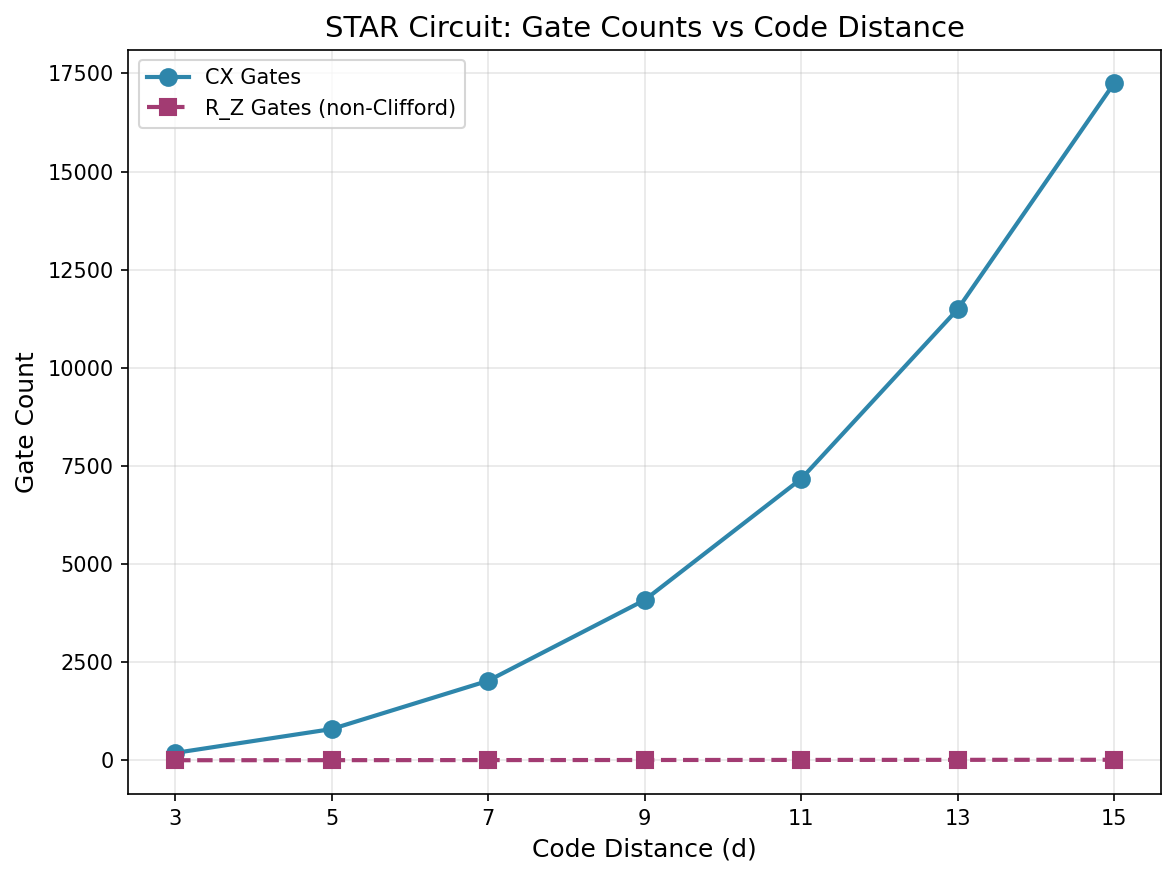

Saved: star_scaling_plots/gate_counts.png


In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

x = df.index.values

ax.plot(x, df['cx_count'], 'o-', color=COLORS['primary'], 
        linewidth=2, markersize=8, label='CX Gates')
ax.plot(x, df['rz_count'], 's--', color=COLORS['secondary'], 
        linewidth=2, markersize=8, label='R_Z Gates (non-Clifford)')

ax.set_xlabel('Code Distance (d)')
ax.set_ylabel('Gate Count')
ax.set_title('STAR Circuit: Gate Counts vs Code Distance')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(x)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gate_counts.png')
plt.show()

print(f"Saved: {OUTPUT_DIR / 'gate_counts.png'}")




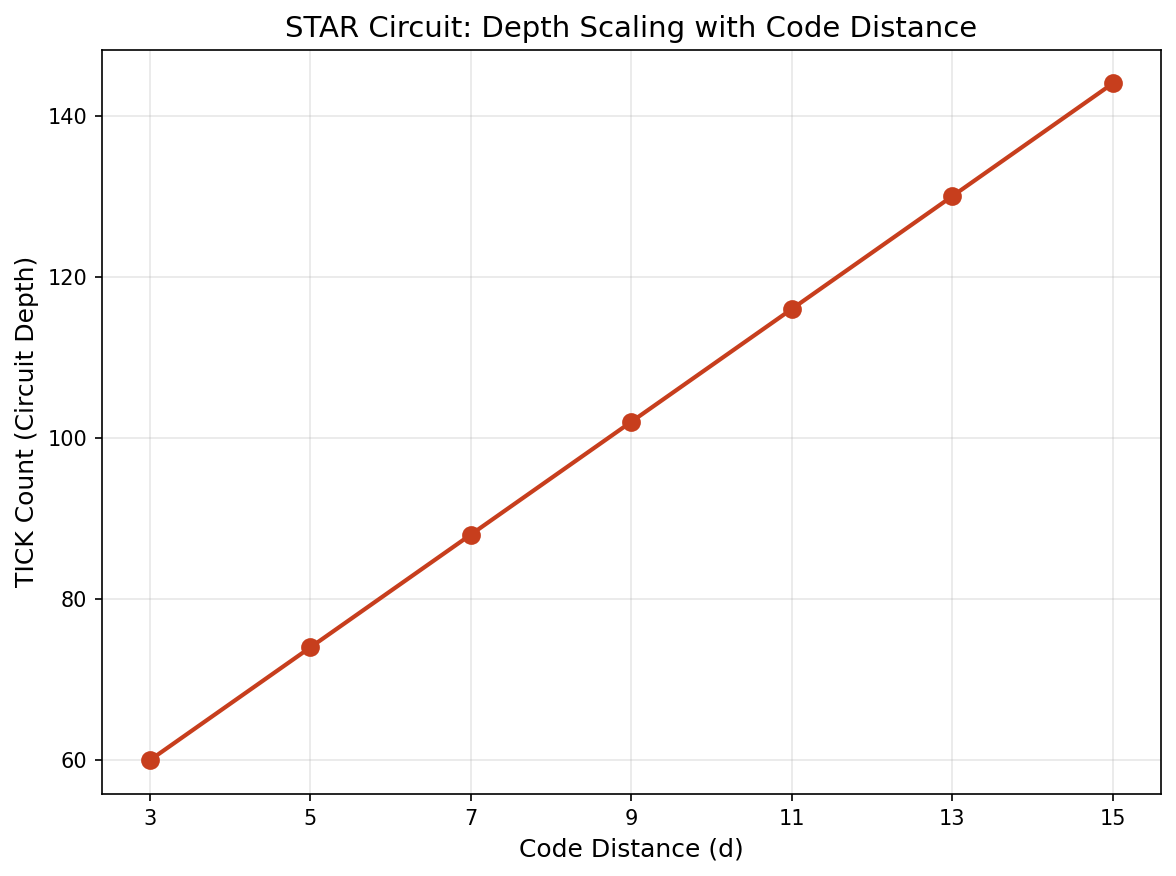

Saved: star_scaling_plots/depth_scaling.png


In [34]:
ffig, ax = plt.subplots(figsize=(8, 6))

x = df.index.values

ax.plot(x, df['tick_count'], 'o-', color=COLORS['quaternary'], 
        linewidth=2, markersize=8)

ax.set_xlabel('Code Distance (d)')
ax.set_ylabel('TICK Count (Circuit Depth)')
ax.set_title('STAR Circuit: Depth Scaling with Code Distance')
ax.grid(True, alpha=0.3)
ax.set_xticks(x)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'depth_scaling.png')
plt.show()

print(f"Saved: {OUTPUT_DIR / 'depth_scaling.png'}")


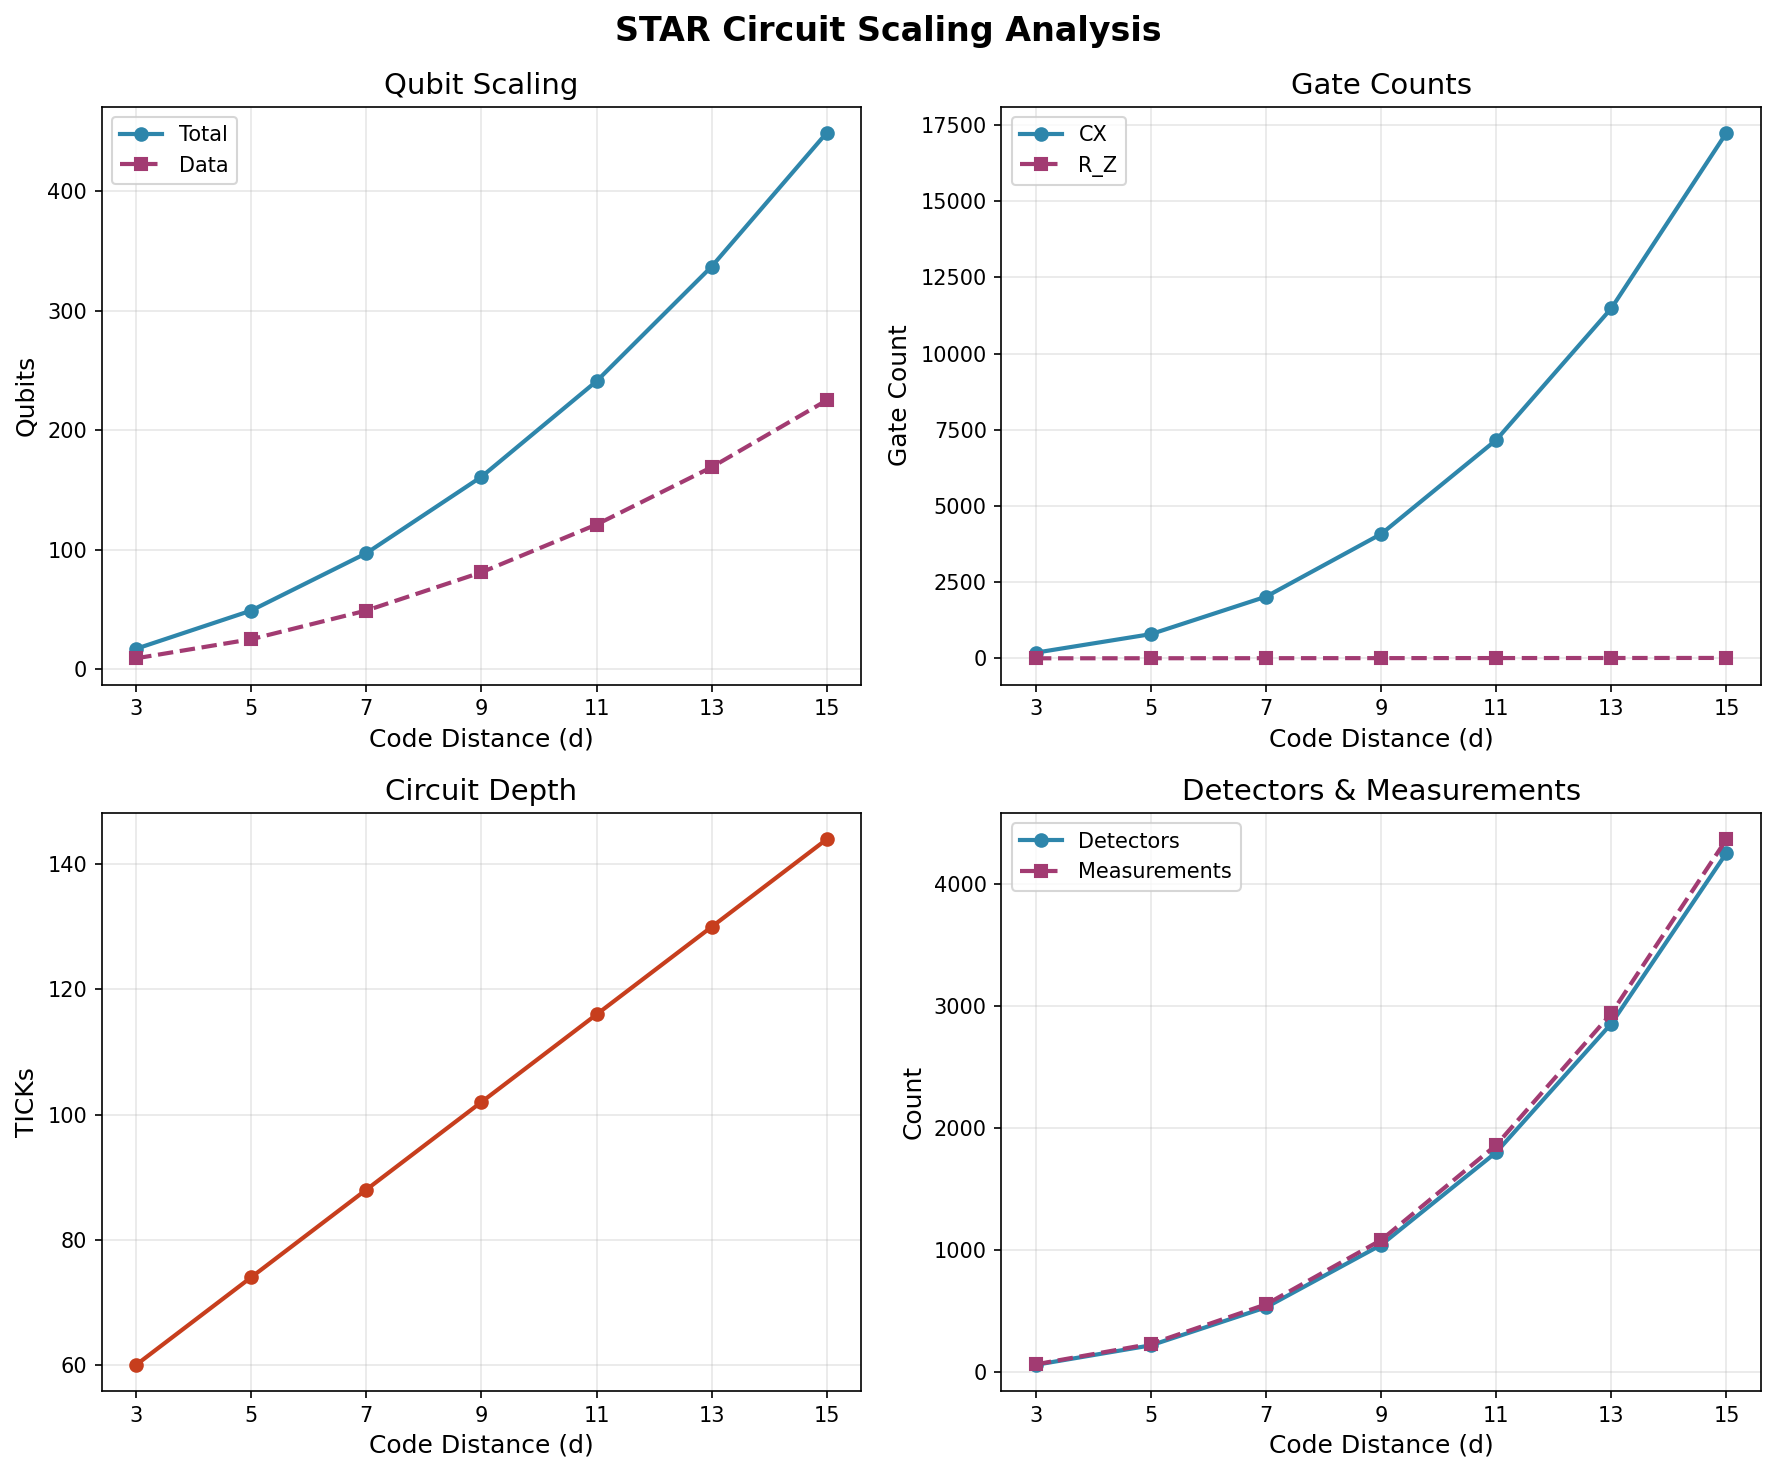

Saved: star_scaling_plots/combined_summary.png


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

x = df.index.values

# Top-left: Qubits
axes[0, 0].plot(x, df['total_qubits'], 'o-', color=COLORS['primary'], linewidth=2, markersize=6, label='Total')
axes[0, 0].plot(x, df['data_qubits'], 's--', color=COLORS['secondary'], linewidth=2, markersize=6, label='Data')
axes[0, 0].set_xlabel('Code Distance (d)')
axes[0, 0].set_ylabel('Qubits')
axes[0, 0].set_title('Qubit Scaling')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(x)

# Top-right: Gates
axes[0, 1].plot(x, df['cx_count'], 'o-', color=COLORS['primary'], linewidth=2, markersize=6, label='CX')
axes[0, 1].plot(x, df['rz_count'], 's--', color=COLORS['secondary'], linewidth=2, markersize=6, label='R_Z')
axes[0, 1].set_xlabel('Code Distance (d)')
axes[0, 1].set_ylabel('Gate Count')
axes[0, 1].set_title('Gate Counts')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(x)

# Bottom-left: Depth
axes[1, 0].plot(x, df['tick_count'], 'o-', color=COLORS['quaternary'], linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Code Distance (d)')
axes[1, 0].set_ylabel('TICKs')
axes[1, 0].set_title('Circuit Depth')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(x)

# Bottom-right: Detectors
axes[1, 1].plot(x, df['detector_count'], 'o-', color=COLORS['primary'], linewidth=2, markersize=6, label='Detectors')
axes[1, 1].plot(x, df['measurement_count'], 's--', color=COLORS['secondary'], linewidth=2, markersize=6, label='Measurements')
axes[1, 1].set_xlabel('Code Distance (d)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Detectors & Measurements')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(x)

plt.suptitle('STAR Circuit Scaling Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'combined_summary.png')
plt.show()

print(f"Saved: {OUTPUT_DIR / 'combined_summary.png'}")



In [40]:
# Save metrics to CSV for reference
csv_path = OUTPUT_DIR / 'star_metrics.csv'
df.to_csv(csv_path)

print(f"Saved metrics to: {csv_path}")
print("\nFinal DataFrame:")
display(df)


Saved metrics to: star_scaling_plots/star_metrics.csv

Final DataFrame:


,data_qubits,total_qubits,ancilla_qubits,cx_count,rz_count,tick_count,detector_count,measurement_count,depol1_count,depol2_count
distance,,,,,,,,,,
3,9,17,8,190,4,60,56,60,58,28
5,25,49,24,798,6,74,216,228,74,36
7,49,97,48,2028,8,88,528,552,90,44
9,81,161,80,4084,10,102,1040,1080,106,52
11,121,241,120,7170,12,116,1800,1860,122,60
13,169,337,168,11490,14,130,2856,2940,138,68
15,225,449,224,17248,16,144,4256,4368,154,76


In [41]:
# Print scaling relationships
print("STAR Circuit Scaling Summary")
print("=" * 60)
print(f"\nCode distances analyzed: {list(df.index)}")
print(f"\nQubit scaling:")
print(f"  d=3:  {df.loc[3, 'total_qubits']} total qubits")
print(f"  d=15: {df.loc[15, 'total_qubits']} total qubits")
print(f"  Ratio: {df.loc[15, 'total_qubits'] / df.loc[3, 'total_qubits']:.1f}x")

print(f"\nCX gate scaling:")
print(f"  d=3:  {df.loc[3, 'cx_count']} CX gates")
print(f"  d=15: {df.loc[15, 'cx_count']} CX gates")
print(f"  Ratio: {df.loc[15, 'cx_count'] / df.loc[3, 'cx_count']:.1f}x")

print(f"\nDepth scaling:")
print(f"  d=3:  {df.loc[3, 'tick_count']} ticks")
print(f"  d=15: {df.loc[15, 'tick_count']} ticks")
print(f"  Ratio: {df.loc[15, 'tick_count'] / df.loc[3, 'tick_count']:.1f}x")

print(f"\nAll plots saved to: {OUTPUT_DIR.absolute()}")


STAR Circuit Scaling Summary

Code distances analyzed: [3, 5, 7, 9, 11, 13, 15]

Qubit scaling:
  d=3:  17 total qubits
  d=15: 449 total qubits
  Ratio: 26.4x

CX gate scaling:
  d=3:  190 CX gates
  d=15: 17248 CX gates
  Ratio: 90.8x

Depth scaling:
  d=3:  60 ticks
  d=15: 144 ticks
  Ratio: 2.4x

All plots saved to: /Users/bruh/YQuantum/QuEra-Challenge/star_scaling_plots
